In [1]:
from skimage import feature
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal
import os
from pathlib import Path
import sys
from sklearn.model_selection import train_test_split, cross_val_score
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from sklearn.metrics import accuracy_score, classification_report, average_precision_score
from sklearn.metrics import precision_recall_curve

from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier as DTC
from sklearn.ensemble import RandomForestClassifier as RFC
from sklearn.neighbors import KNeighborsClassifier as KNN
import xgboost as XGB


In [2]:
parent_folder = Path().resolve().parent
src_path = parent_folder / 'src'
sys.path.append(str(src_path))

from tools import get_embedding_birdnet

#env to use: clef

In [3]:
root_folder='../data/test_data_3/embedding/'

In [4]:
df_pos = get_embedding_birdnet(root_folder, 1)
df_neg = get_embedding_birdnet(root_folder, 0)

In [6]:
#df_selections = pd.read_csv("../data/Holderried/selections_train_val.csv")

In [5]:
df_pos["selec"] = (
    df_pos["embed_name"]
    .str.extract(r"^(\d+)")
    .astype(int)
)


In [6]:
df_pos["filename"] = df_pos["embed_name"].str.split("_").str[0]

In [7]:
df_neg["filename"] = df_neg["embed_name"].str.split("_").str[0]

In [8]:
df_neg.head(2)

,embed_name,embedding,filename
0,1116_0.birdnet.embeddings.txt,"[0.0, 0.1607482, 0.11047729, 0.45006192, 0.953...",1116
1,1116_3.birdnet.embeddings.txt,"[0.0, 0.092793345, 0.45188978, 0.2304986, 0.69...",1116


In [9]:
df_pos['target'] = 1
df_neg['target'] = 0

In [10]:
from sklearn.model_selection import GroupKFold, cross_val_score

# Combine and shuffle
df_combined = pd.concat([df_pos, df_neg], ignore_index=True)
df_combined = df_combined.sample(frac=1, random_state=22).reset_index(drop=True)

# Features, labels, groups
X = np.vstack(df_combined["embedding"].values)
y = df_combined["target"].values
groups = df_combined["filename"].values

# 5-fold grouped CV
cv = GroupKFold(n_splits=5)

SVM

In [16]:
from sklearn.svm import SVC

model = SVC(kernel="rbf", cache_size=300)

accuracies = cross_val_score(
    model,
    X,
    y,
    cv=cv,
    groups=groups,
    scoring="accuracy"
)


ap = cross_val_score(
    model,
    X,
    y,
    cv=cv,
    groups=groups,
    scoring="average_precision"
)

print(f"Accuracy: {accuracies.mean():.4f} ± {accuracies.std(ddof=1):.4f}")
print(f"AP: {ap.mean():.4f} ± {ap.std(ddof=1):.4f}")

Accuracy: 0.8193 ± 0.0344
AP: 0.8741 ± 0.0070


Random Forest

In [14]:
model = RFC(n_jobs = -1)
model = DTC()

accuracies = cross_val_score(
    model,
    X,
    y,
    cv=cv,
    groups=groups,
    scoring="accuracy"
)


ap = cross_val_score(
    model,
    X,
    y,
    cv=cv,
    groups=groups,
    scoring="average_precision"
)

print(f"Accuracy: {accuracies.mean():.4f} ± {accuracies.std(ddof=1):.4f}")
print(f"AP: {ap.mean():.4f} ± {ap.std(ddof=1):.4f}")

Accuracy: 0.6713 ± 0.0537
AP: 0.5141 ± 0.0432


MODEL SAVING

In [17]:
import os
import joblib
import numpy as np

from sklearn.model_selection import GroupKFold
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, average_precision_score
from sklearn.metrics import confusion_matrix

cv = GroupKFold(n_splits=5)

accuracies = []
aps = []
confusion_matrices = []

os.makedirs("saved_models", exist_ok=True)

for fold, (train_idx, test_idx) in enumerate(cv.split(X, y, groups), start=1):

    X_train, X_test = X[train_idx], X[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]

    model = SVC(kernel="rbf", cache_size=500)
    #model = RFC(n_jobs = -1)

    model.fit(X_train, y_train)

    # Save model
    joblib.dump(model, f"saved_models/svm_fold_{fold}.joblib")

    # Evaluate
    y_pred = model.predict(X_test)

    y_score = model.decision_function(X_test) # SVC

    ## RFC
    #y_score = model.predict_proba(X_test)[:, 1]

    accuracies.append(accuracy_score(y_test, y_pred))
    aps.append(average_precision_score(y_test, y_score))
    cm = confusion_matrix(y_test, y_pred)
    confusion_matrices.append(cm)

    np.savetxt(
        f"saved_models/svm_confusion_matrix_fold_{fold}.csv",
        cm,
        fmt="%d",
        delimiter=","
    )

print("Accuracy per fold:", np.round(accuracies, 4))
print(f"Accuracy: {np.mean(accuracies):.4f} ± {np.std(accuracies, ddof=1):.4f}")

print("AP per fold:", np.round(aps, 4))
print(f"AP: {np.mean(aps):.4f} ± {np.std(aps, ddof=1):.4f}")

Accuracy per fold: [0.9921 0.966  0.9966 0.9989 0.9705]
Accuracy: 0.9848 ± 0.0154
AP per fold: [0.9985 0.9985 1.     1.     0.9992]
AP: 0.9992 ± 0.0007


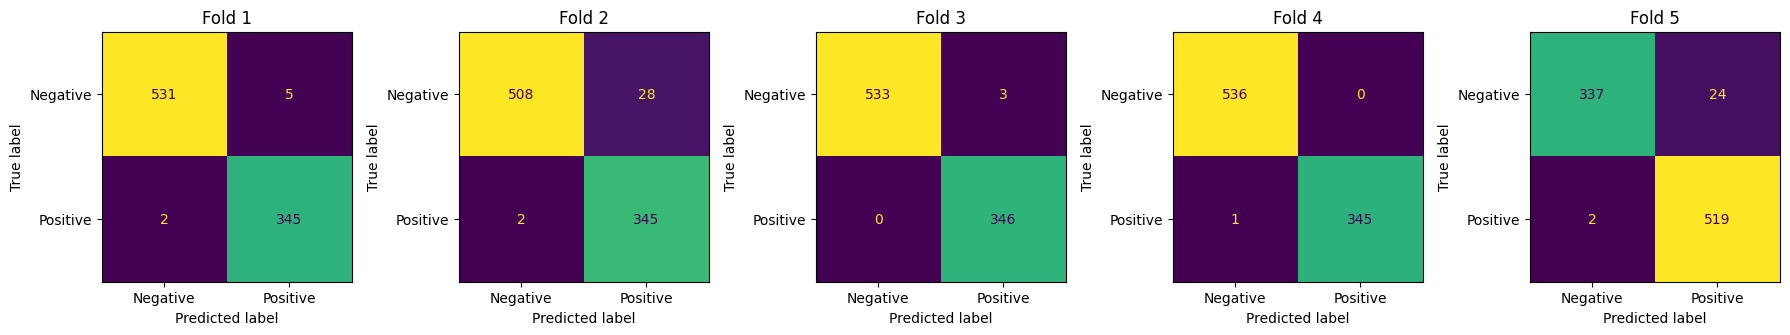

In [18]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

fig, axes = plt.subplots(1, 5, figsize=(18, 4))

for i, cm in enumerate(confusion_matrices):
    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=["Negative", "Positive"]
    )
    disp.plot(ax=axes[i], colorbar=False)
    axes[i].set_title(f"Fold {i+1}")

plt.tight_layout()
plt.savefig("./saved_models/svm_confusion_matrices_5fold.png", dpi=300, bbox_inches="tight")
plt.show()

In [11]:
#predictions = model.predict(test)
#ap = average_precision_score(test_target, predictions)
#print("Test set average precision:", ap)

#report=classification_report(test_target, predictions, digits=4)
#print(report)

# Only for binary classification (adjust for multi-class)
#precision, recall, thr = precision_recall_curve(test_target, predictions)


In [12]:
#plt.plot(recall, precision, marker='.')
#plt.xlabel('Recall')
#plt.ylabel('Precision')
#plt.title('Precision-Recall Curve')
#plt.show()